This notebook has demo of the function on Les Miserables data. It is sufficiently sized so we could clearly see the visuals so they can be used in the research paper when required.

## Dataset: Rhesus Macaque Brain Connectivity Network

- **Organism:** Rhesus macaque (*Macaca mulatta*) — neurologically similar 
  to humans, widely used in neuroscience research
- **Vertices (90):** distinct brain regions, each grouping neurons with 
  similar structure and function
- **Edges:** white matter tracts connecting pairs of brain regions — bundles 
  of myelinated nerve fibers enabling signal transmission
- **Undirected:** white matter tracts support bidirectional signal flow
- **Unweighted:** edges indicate existence of a connection, not its strength

### Why This Dataset
- Connection strengths between brain regions are unobservable and vary 
  across individuals
- This uncertainty makes it a natural fit for Monte Carlo uncertainty 
  quantification
- We model unknown transmission capacity as a random permeability field 
  via white noise sampling

### Flow Interpretation
- $\Gamma_{in}$ = peripheral sensory regions (low degree) — signal enters here
- $\Gamma_{out}$ = central processing hubs (high degree) — signal exits here
- $Q$ = total signal flux from sensory periphery to processing hubs under 
  uncertain connection strengthsiphery through the network

In [10]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from two_level_mc import * # adjust if your notebook is nested differently
from functions_v2 import *

In [12]:
import networkx as nx
import numpy as np
from scipy.linalg import eigh
import matplotlib.pyplot as plt
from tqdm import tqdm
import matplotlib.colors as mcolors

# visualise

In [18]:
edges, n_vertices, edge_weights = load_graph("../../data/raw/bn-macaque-rhesus_brain_2.edges")

✓ Loaded: ../../data/raw/bn-macaque-rhesus_brain_2.edges
  Vertices : 91
  Edges    : 582
  Weighted : no



Saved as rhesus_brain_viz.png


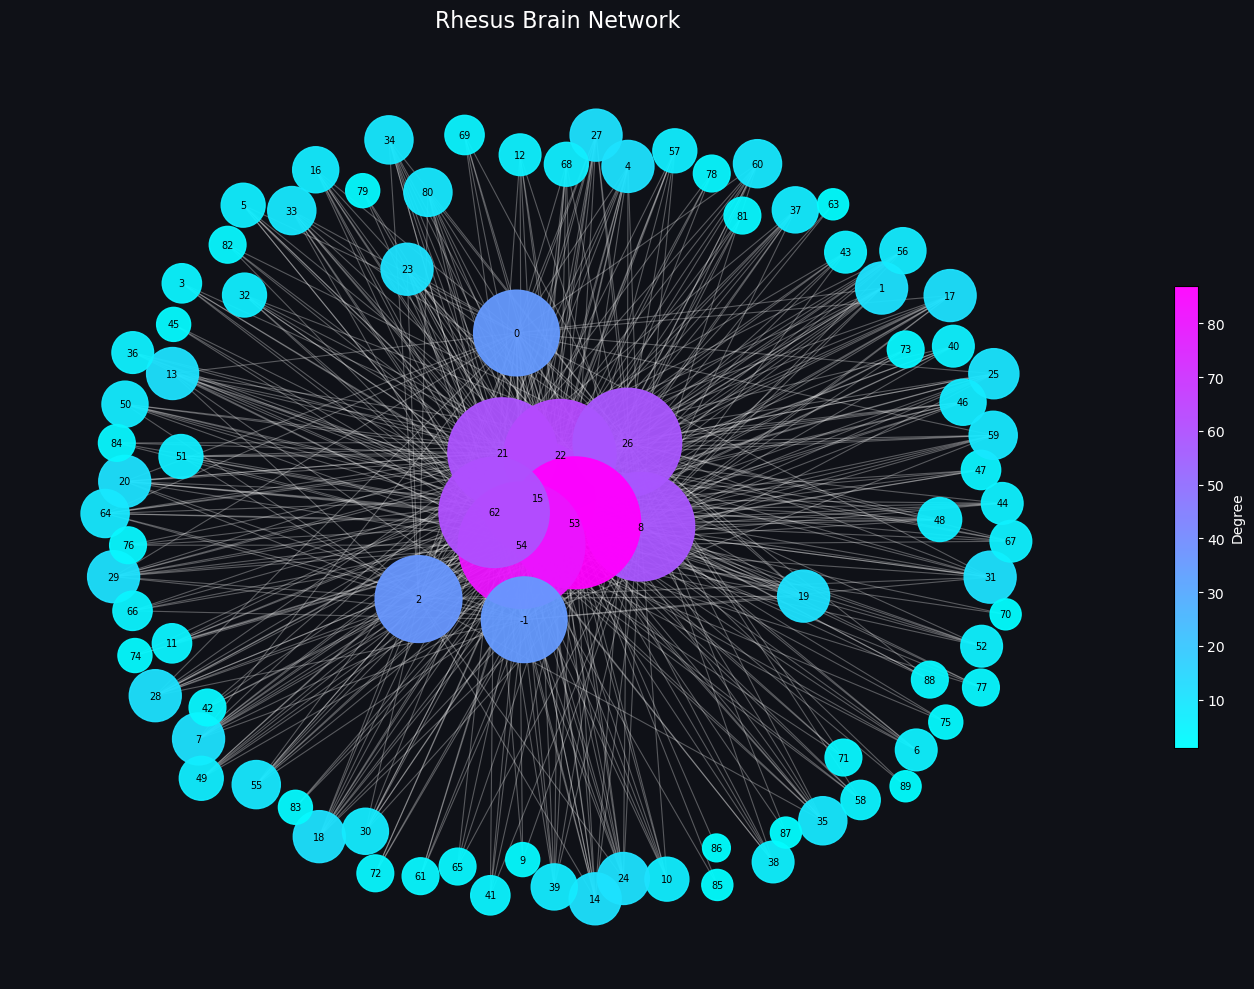

In [8]:
# Paper version
visualize_graph_2d(edges, n_vertices, title="Rhesus Brain Network", save_as="rhesus_brain_viz.png")

In [85]:
def visualize_graph_3d_plotly(edges, n_vertices, edge_weights=None, title="Graph (3D)"):
    """
    Interactive 3D graph visualization using Plotly.
    Fully rotatable — drag to explore the graph structure.
    Node size and color reflect degree.
    """
    G = nx.Graph()
    G.add_nodes_from(range(n_vertices))
    G.add_edges_from(edges)

    degrees = dict(G.degree())

    # 3D spring layout using networkx 2D + spectral for z
    pos_2d = nx.spring_layout(G, seed=42, k=2)
    
    # use second eigenvector of laplacian for z coordinate (more meaningful than random)
    L_mat   = nx.laplacian_matrix(G).toarray().astype(float)
    eigvals, eigvecs = np.linalg.eigh(L_mat)
    z_coord = eigvecs[:, 1]  # Fiedler vector — captures graph structure in z

    pos_3d = {v: (pos_2d[v][0], pos_2d[v][1], z_coord[v]) for v in G.nodes()}

    # edge traces
    edge_x, edge_y, edge_z = [], [], []
    for (i, j) in G.edges():
        x0, y0, z0 = pos_3d[i]
        x1, y1, z1 = pos_3d[j]
        edge_x += [x0, x1, None]
        edge_y += [y0, y1, None]
        edge_z += [z0, z1, None]

    edge_trace = go.Scatter3d(
        x=edge_x, y=edge_y, z=edge_z,
        mode='lines',
        line=dict(width=1, color='rgba(255,255,255,0.3)'),
        hoverinfo='none',
        showlegend=False
    )

    # node traces
    node_x       = [pos_3d[v][0] for v in G.nodes()]
    node_y       = [pos_3d[v][1] for v in G.nodes()]
    node_z       = [pos_3d[v][2] for v in G.nodes()]
    node_degrees = np.array([degrees[v] for v in G.nodes()])
    node_sizes = [3 + degrees[v] * 0.5 for v in G.nodes()]
    node_text    = [f"Vertex {v}<br>Degree: {degrees[v]}" for v in G.nodes()]

    node_trace = go.Scatter3d(
        x=node_x, y=node_y, z=node_z,
        mode='markers+text' if n_vertices <= 50 else 'markers',
        hoverinfo='text',
        text=[str(v) for v in G.nodes()] if n_vertices <= 50 else None,
        hovertext=node_text,
        marker=dict(
            size=node_sizes,
            color=node_degrees,
            colorscale='Viridis',
            cmin=min(node_degrees),
            cmax=max(node_degrees),
            showscale=True,
            colorbar=dict(
                title=dict(text="Degree", font=dict(color="white")),
                tickfont=dict(color="white"),
                thickness=15
            ),
            line=dict(width=0.5, color='white'),
            opacity=0.9
        ),
    showlegend=False
    )

    fig = go.Figure(
        data=[edge_trace, node_trace],
        layout=go.Layout(
            title=dict(text=title, font=dict(color='white', size=16)),
            paper_bgcolor='#0f1117',
            height=800,
            width=1200,
            scene=dict(
                xaxis=dict(showgrid=False, zeroline=False,
                           showticklabels=False, backgroundcolor='#0f1117',
                           showspikes=False),
                yaxis=dict(showgrid=False, zeroline=False,
                           showticklabels=False, backgroundcolor='#0f1117',
                           showspikes=False),
                zaxis=dict(showgrid=False, zeroline=False,
                           showticklabels=False, backgroundcolor='#0f1117',
                           showspikes=False),
                bgcolor='#0f1117',
                camera=dict(
                    eye=dict(x=1.5, y=1.5, z=1.5)
                )
            ),
            margin=dict(l=0, r=0, t=50, b=0)
        )
    )
    fig.show()
    return fig

In [ ]:
fig_3d = visualize_graph_3d_plotly(edges, n_vertices, edge_weights=None, title="Graph (3D)")
fig_3d.write_html("rhesus_3d.html")
print("Saved — open rhesus_3d.html in your browser")

Saved — open rhesus_3d.html in your browser


# Phase 0

In [10]:
print(f"Vertices : {n_vertices}")
print(f"Edges    : {len(edges)}")

Vertices : 90
Edges    : 582


# Phase 1

In [20]:
A, D, L = build_graph_matrices(edges, n_vertices, edge_weights)

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 91 x 91
  Degree range: [1, 87]
  Non-zeros in L: 1255



# Phase 2

In [22]:
# Phase 2: Compute lambda_min and build shifted Laplacian
lambda_min = compute_lambda_min(L, D)
L_sigma    = build_shifted_laplacian(L, D, lambda_min, sigma_squared=0.25)

✓ lambda_min = 0.633535
  (eigenvalues found: [0.         0.63353502])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse



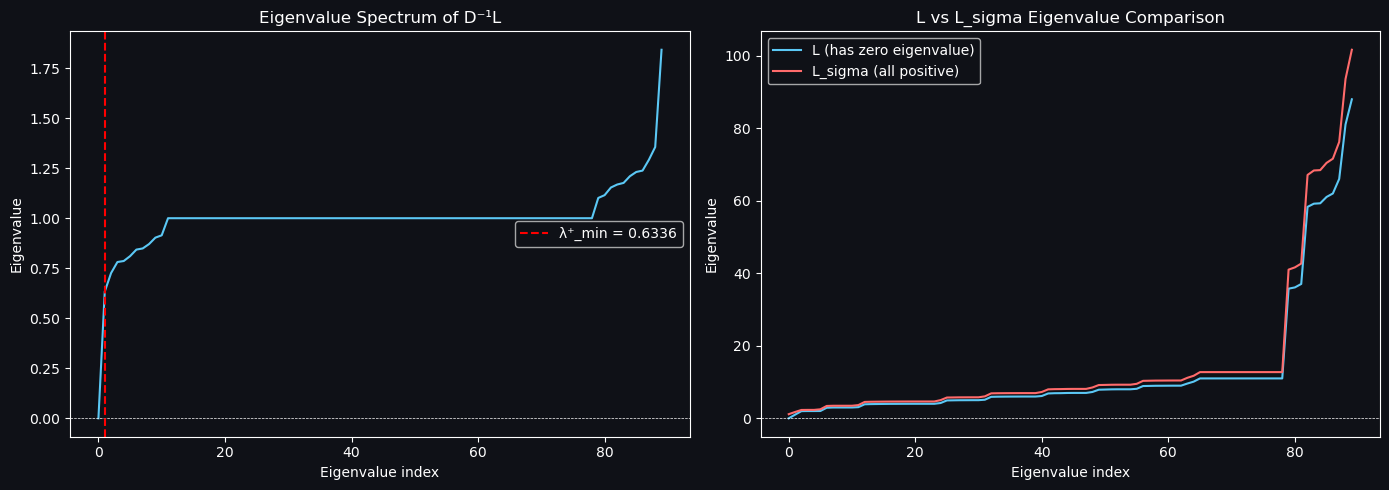

λ⁺_min = 0.633608
Smallest eigenvalue of L_sigma = 1.135737 (should be > 0)


In [16]:
# phase 2 visual
# Compute all eigenvalues of D^{-1}L
eigenvalues, _ = eigh(L, D)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f1117")

for ax in axes:
    ax.set_facecolor("#0f1117")
    ax.tick_params(colors="white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor("white")

# Plot 1: full eigenvalue spectrum
axes[0].plot(eigenvalues, color="#5bc8f5", linewidth=1.5)
axes[0].axhline(0, color="white", linewidth=0.5, linestyle="--")
axes[0].axvline(1, color="red", linewidth=1.5, linestyle="--",
                label=f"λ⁺_min = {lambda_min:.4f}")
axes[0].set_xlabel("Eigenvalue index")
axes[0].set_ylabel("Eigenvalue")
axes[0].set_title("Eigenvalue Spectrum of D⁻¹L")
axes[0].legend(facecolor="#0f1117", labelcolor="white")

# Plot 2: compare L vs L_sigma eigenvalues
eig_L      = np.linalg.eigvalsh(L)
eig_Lsigma = np.linalg.eigvalsh(L_sigma)

axes[1].plot(eig_L,      color="#5bc8f5", linewidth=1.5, label="L (has zero eigenvalue)")
axes[1].plot(eig_Lsigma, color="#ff6b6b", linewidth=1.5, label="L_sigma (all positive)")
axes[1].axhline(0, color="white", linewidth=0.5, linestyle="--")
axes[1].set_xlabel("Eigenvalue index")
axes[1].set_ylabel("Eigenvalue")
axes[1].set_title("L vs L_sigma Eigenvalue Comparison")
axes[1].legend(facecolor="#0f1117", labelcolor="white")

plt.tight_layout()
plt.savefig("rhesus_phase2.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"λ⁺_min = {lambda_min:.6f}")
print(f"Smallest eigenvalue of L_sigma = {eig_Lsigma[0]:.6f} (should be > 0)")

# Phase 3

In [24]:
# set seed for reproducibility
np.random.seed(42)

# run phase 3
u, B, cho_cache = run_phase3(L_sigma, lambda_min, edges, n_vertices)

✓ Phase 3 complete: correlated field u generated
  u range: [-0.9337, 0.5929]



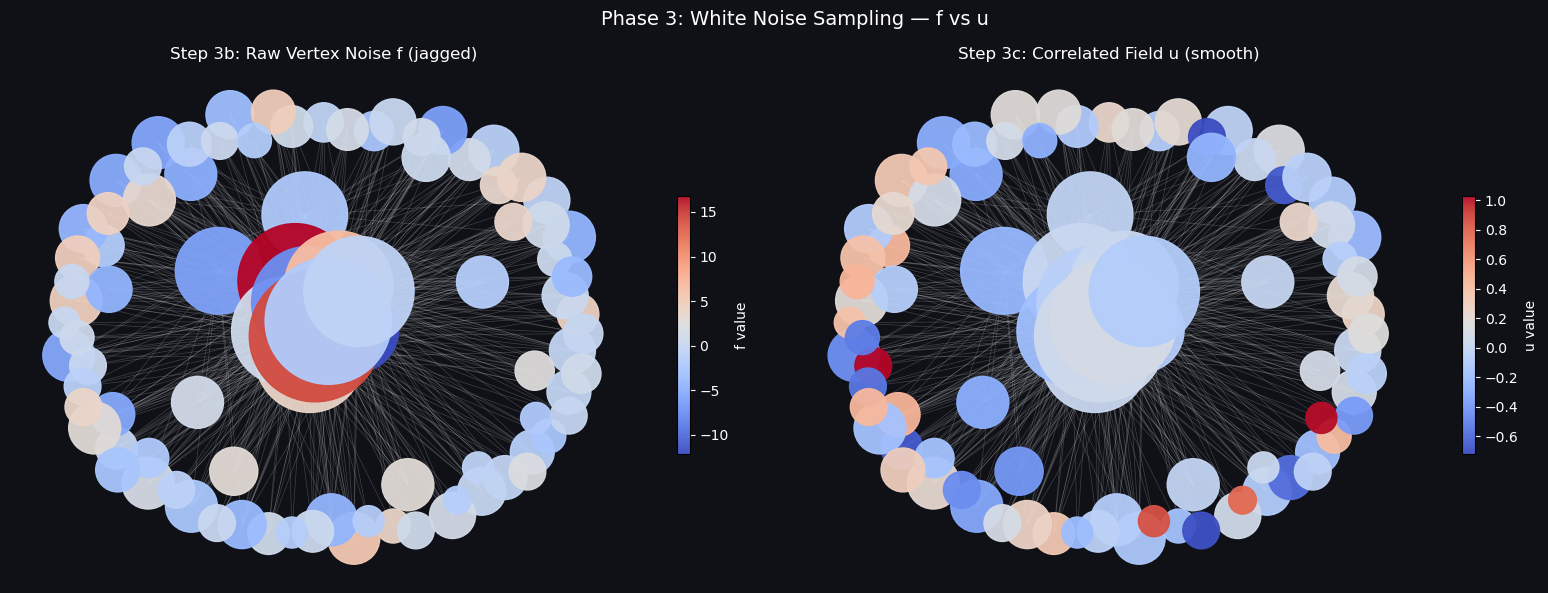

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#0f1117")

for ax in axes:
    ax.set_facecolor("#0f1117")
    ax.axis("off")

G_vis = nx.Graph()
G_vis.add_nodes_from(range(n_vertices))  # force 0-indexed nodes
G_vis.add_edges_from(edges)

degrees_vis = dict(G_vis.degree())
pos         = nx.spring_layout(G_vis, seed=42, k=2)
nodelist    = list(range(n_vertices))    # explicit 0-indexed nodelist
node_sizes  = [300 + degrees_vis[v] * 100 for v in nodelist]

# Left: f (raw vertex noise — jagged)
f_demo = B @ np.random.randn(len(edges))
nc1 = nx.draw_networkx_nodes(G_vis, pos, ax=axes[0], nodelist=nodelist,
                              node_size=node_sizes,
                              node_color=[f_demo[v] for v in nodelist],
                              cmap=plt.cm.coolwarm, alpha=0.95)
nx.draw_networkx_edges(G_vis, pos, ax=axes[0], edge_color="white", width=0.5, alpha=0.2)
cb1 = plt.colorbar(nc1, ax=axes[0], shrink=0.5)
cb1.set_label("f value", color="white")
cb1.ax.yaxis.set_tick_params(color="white")
plt.setp(cb1.ax.yaxis.get_ticklabels(), color="white")
axes[0].set_title("Step 3b: Raw Vertex Noise f (jagged)", color="white", fontsize=12)

# Right: u (correlated field — smooth)
nc2 = nx.draw_networkx_nodes(G_vis, pos, ax=axes[1], nodelist=nodelist,
                              node_size=node_sizes,
                              node_color=[u[v] for v in nodelist],
                              cmap=plt.cm.coolwarm, alpha=0.95)
nx.draw_networkx_edges(G_vis, pos, ax=axes[1], edge_color="white", width=0.5, alpha=0.2)
cb2 = plt.colorbar(nc2, ax=axes[1], shrink=0.5)
cb2.set_label("u value", color="white")
cb2.ax.yaxis.set_tick_params(color="white")
plt.setp(cb2.ax.yaxis.get_ticklabels(), color="white")
axes[1].set_title("Step 3c: Correlated Field u (smooth)", color="white", fontsize=12)

plt.suptitle("Phase 3: White Noise Sampling — f vs u", color="white", fontsize=14)
plt.tight_layout()
plt.savefig("rhesus_phase3.png", dpi=150, bbox_inches="tight")
plt.show()

In [45]:
# ---- Shared setup (reuse from your working version) ----
G_vis = nx.Graph()
G_vis.add_nodes_from(range(n_vertices))
G_vis.add_edges_from(edges)
degrees_vis = dict(G_vis.degree())
pos = nx.spring_layout(G_vis, seed=42, k=2)
nodelist = list(range(n_vertices))

# smaller node sizes -- reduced base size and degree multiplier
node_sizes = [80 + degrees_vis[v] * 25 for v in nodelist]

f_demo = B @ np.random.randn(len(edges))

# ---- Figure 1: f only ----
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("none")
ax.set_facecolor("none")
ax.axis("off")

nc1 = nx.draw_networkx_nodes(G_vis, pos, ax=ax, nodelist=nodelist,
                              node_size=node_sizes,
                              node_color=[f_demo[v] for v in nodelist],
                              cmap=plt.cm.coolwarm, alpha=0.95)
nx.draw_networkx_edges(G_vis, pos, ax=ax, edge_color="white", width=0.5, alpha=0.2)
cb1 = plt.colorbar(nc1, ax=ax, shrink=0.6)
cb1.set_label("f value", color="white")
cb1.ax.yaxis.set_tick_params(color="white")
plt.setp(cb1.ax.yaxis.get_ticklabels(), color="white")
ax.set_title("Raw Vertex Noise f (jagged)", color="white", fontsize=14)

plt.tight_layout()
plt.savefig("rhesus_f_only.png", dpi=200, bbox_inches="tight", facecolor="#0f1117")
plt.close()

# ---- Figure 2: u only ----
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0f1117")
ax.set_facecolor("#0f1117")
ax.axis("off")

nc2 = nx.draw_networkx_nodes(G_vis, pos, ax=ax, nodelist=nodelist,
                              node_size=node_sizes,
                              node_color=[u[v] for v in nodelist],
                              cmap=plt.cm.coolwarm, alpha=0.95)
nx.draw_networkx_edges(G_vis, pos, ax=ax, edge_color="white", width=0.5, alpha=0.2)
cb2 = plt.colorbar(nc2, ax=ax, shrink=0.6)
cb2.set_label("u value", color="white")
cb2.ax.yaxis.set_tick_params(color="white")
plt.setp(cb2.ax.yaxis.get_ticklabels(), color="white")
ax.set_title("Correlated Field u (smooth)", color="white", fontsize=14)

plt.tight_layout()
plt.savefig("rhesus_u_only.png", dpi=200, bbox_inches="tight", facecolor="#0f1117")
plt.close()

print("saved rhesus_f_only.png and rhesus_u_only.png separately")

saved rhesus_f_only.png and rhesus_u_only.png separately


In [50]:
# ---- Degree-based gamma selection: hub = source, periphery = sink ----
degrees_arr = np.array(A.sum(axis=1)).flatten()

low_threshold = np.percentile(degrees_arr, 10)
high_threshold = np.percentile(degrees_arr, 90)

gamma_in = [v for v in range(n_vertices) if degrees_arr[v] >= high_threshold]
gamma_out = [v for v in range(n_vertices) if degrees_arr[v] <= low_threshold]

print(f"gamma_in (hub, source, p=1): {len(gamma_in)} vertices")
print(f"gamma_out (periphery, sink, p=0): {len(gamma_out)} vertices")

boundary_fraction = (len(gamma_in) + len(gamma_out)) / n_vertices
print(f"boundary fraction: {boundary_fraction:.4f}")

gamma_in (hub, source, p=1): 11 vertices
gamma_out (periphery, sink, p=0): 12 vertices
boundary fraction: 0.2527


In [54]:
# ---- Degree-based gamma selection: hub = source, periphery = sink ----
degrees_arr = np.array(A.sum(axis=1)).flatten()

low_threshold = np.percentile(degrees_arr, 10)
high_threshold = np.percentile(degrees_arr, 90)

gamma_in = [v for v in range(n_vertices) if degrees_arr[v] >= high_threshold]
gamma_out = [v for v in range(n_vertices) if degrees_arr[v] <= low_threshold]

print(f"gamma_in (hub, source, p=1): {len(gamma_in)} vertices")
print(f"gamma_out (periphery, sink, p=0): {len(gamma_out)} vertices")

boundary_fraction = (len(gamma_in) + len(gamma_out)) / n_vertices
print(f"boundary fraction: {boundary_fraction:.4f}")

gamma_in (hub, source, p=1): 11 vertices
gamma_out (periphery, sink, p=0): 12 vertices
boundary fraction: 0.2527


In [56]:
# ---- assumes edges, n_vertices, u, G_vis, pos, node_sizes already exist from your Slide 3 setup ----

# Build k_e from u (Phase 4)
i_arr = np.array([e[0] for e in edges])
j_arr = np.array([e[1] for e in edges])
k_vals = np.exp((u[i_arr] + u[j_arr]) / 2)

# Build L_k and solve Darcy flow (Phase 5) -- use your actual gamma_in/gamma_out
L_k = build_weighted_laplacian(edges, n_vertices, k_vals)  # adjust to your actual function signature
p = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)       # adjust to your actual function

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("none")
ax.set_facecolor("none")
ax.axis("off")

nc = nx.draw_networkx_nodes(G_vis, pos, ax=ax, nodelist=nodelist,
                              node_size=node_sizes,
                              node_color=[p[v] for v in nodelist],
                              cmap=plt.cm.coolwarm, vmin=0, vmax=1, alpha=0.95)
nx.draw_networkx_edges(G_vis, pos, ax=ax, edge_color="white", width=0.5, alpha=0.2)
cb = plt.colorbar(nc, ax=ax, shrink=0.6)
cb.set_label("p value", color="white")
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")
ax.set_title("Pressure Field p (source → sink)", color="white", fontsize=14)

plt.tight_layout()
plt.savefig("rhesus_p_only.png", dpi=200, bbox_inches="tight", transparent=True)
plt.close()

In [59]:
print(f"n_vertices: {n_vertices}")
print(f"G_vis.number_of_nodes(): {G_vis.number_of_nodes()}")
print(f"len(nodelist): {len(nodelist)}")

n_vertices: 91
G_vis.number_of_nodes(): 91
len(nodelist): 91


In [61]:
print(f"p range: [{p.min():.4f}, {p.max():.4f}]")
print(f"p mean: {p.mean():.4f}")
print(f"p at gamma_in vertices: {[p[v] for v in gamma_in[:5]]}")
print(f"p at gamma_out vertices: {[p[v] for v in gamma_out[:5]]}")

p range: [0.0000, 1.0000]
p mean: 0.8681
p at gamma_in vertices: [1.0, 1.0, 1.0, 1.0, 1.0]
p at gamma_out vertices: [0.0, 0.0, 0.0, 0.0, 0.0]


In [65]:
import matplotlib.colors as mcolors
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("none")
ax.set_facecolor("none")
ax.axis("off")

# Apply the power transform manually to the p values themselves,
# then let draw_networkx_nodes use plain linear vmin/vmax on the transformed values
p_values = np.array([p[v] for v in nodelist])
p_transformed = np.power(p_values, 0.4)   # same effect as PowerNorm(gamma=0.4)

nc = nx.draw_networkx_nodes(G_vis, pos, ax=ax, nodelist=nodelist,
                              node_size=node_sizes,
                              node_color=p_transformed,
                              cmap=plt.cm.coolwarm, vmin=0, vmax=1, alpha=0.95)
nx.draw_networkx_edges(G_vis, pos, ax=ax, edge_color="white", width=0.5, alpha=0.2)

# Build the colorbar manually, since the automatic one would show the
# TRANSFORMED scale (0 to 1, power-stretched) rather than the real p values
cb = plt.colorbar(nc, ax=ax, shrink=0.6)
cb.set_label("p value (power-stretched for visibility)", color="white")
cb.ax.yaxis.set_tick_params(color="white")
plt.setp(cb.ax.yaxis.get_ticklabels(), color="white")

ax.set_title("Pressure Field p (source → sink)", color="white", fontsize=14)

plt.tight_layout()
plt.savefig("rhesus_p_only.png", dpi=200, bbox_inches="tight", transparent=True)
plt.close()

print("saved rhesus_p_only.png")

saved rhesus_p_only.png


In [69]:
p_values = np.array([p[v] for v in nodelist])
p_transformed = np.power(p_values, 0.4)

print("Original p range:", p_values.min(), p_values.max())
print("Transformed p range:", p_transformed.min(), p_transformed.max())
print("Original p values (sample):", np.round(p_values[:15], 3))
print("Transformed p values (sample):", np.round(p_transformed[:15], 3))

Original p range: 0.0 1.0000000000000002
Transformed p range: 0.0 1.0
Original p values (sample): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]
Transformed p values (sample): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]


In [71]:
boundary_set = set(gamma_in) | set(gamma_out)
interior_indices = [v for v in range(n_vertices) if v not in boundary_set]

interior_p = np.array([p[v] for v in interior_indices])
print(f"Number of interior vertices: {len(interior_indices)}")
print(f"Interior p range: [{interior_p.min():.4f}, {interior_p.max():.4f}]")
print(f"Interior p values (sample): {np.round(interior_p[:15], 3)}")
print(f"Interior p std: {interior_p.std():.4f}")

Number of interior vertices: 68
Interior p range: [1.0000, 1.0000]
Interior p values (sample): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Interior p std: 0.0000


In [73]:
print(f"L_k shape: {L_k.shape}")
print(f"L_k nnz: {L_k.nnz}")
row_sums = np.array(L_k.sum(axis=1)).flatten()
print(f"L_k row sums (should be ~0): max deviation = {np.abs(row_sums).max():.2e}")

L_k shape: (91, 91)
L_k nnz: 1255
L_k row sums (should be ~0): max deviation = 2.04e-14


# Run the entire pipeline on rhesus

In [78]:
import sys
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project")
sys.path.append(r"C:\Users\Rakesh\Documents\summer-project\src")

from functions_v2 import *
from two_level_mc import TwoLevelSetup
from graph_mlmc_model import GraphTwoLevelModel
from mlmc_runner import MLMCRunner
from sksparse.cholmod import cholesky as sparse_cholesky

In [84]:
edges, n_vertices, weights = load_graph(r"../../data/raw/bn-macaque-rhesus_brain_2.edges")
print(f"n_vertices={n_vertices}, edges={len(edges)}")

✓ Loaded: ../../data/raw/bn-macaque-rhesus_brain_2.edges
  Vertices : 91
  Edges    : 582
  Weighted : no

n_vertices=91, edges=582


In [87]:
# 3. Phase 1
A, D, L = build_graph_matrices(edges, n_vertices)

# 4. Phase 2 — sparse from the start, given graph size
lambda_min = compute_lambda_min(L, D)
L_sigma = build_shifted_laplacian(L, D, lambda_min)
print("L_sigma type:", type(L_sigma))

✓ Phase 1 complete: A, D, L built as sparse matrices
  Matrix size : 91 x 91
  Degree range: [1, 87]
  Non-zeros in L: 1255

✓ lambda_min = 0.633535
  (eigenvalues found: [0.         0.63353502])
✓ Phase 2 complete: L_sigma built (sigma^2 = 0.25)
  L_sigma type: sparse

L_sigma type: <class 'scipy.sparse._csc.csc_matrix'>


In [90]:
G_nx = nx.Graph()
G_nx.add_edges_from(edges)

In [92]:
# ---- Degree-based gamma selection: hub = source, periphery = sink ----
degrees_arr = np.array(A.sum(axis=1)).flatten()

low_threshold = np.percentile(degrees_arr, 10)
high_threshold = np.percentile(degrees_arr, 90)

gamma_in = [v for v in range(n_vertices) if degrees_arr[v] >= high_threshold]
gamma_out = [v for v in range(n_vertices) if degrees_arr[v] <= low_threshold]

print(f"gamma_in (hub, source, p=1): {len(gamma_in)} vertices")
print(f"gamma_out (periphery, sink, p=0): {len(gamma_out)} vertices")

boundary_fraction = (len(gamma_in) + len(gamma_out)) / n_vertices
print(f"boundary fraction: {boundary_fraction:.4f}")

gamma_in (hub, source, p=1): 11 vertices
gamma_out (periphery, sink, p=0): 12 vertices
boundary fraction: 0.2527


In [95]:
print(f"gamma_in: {len(gamma_in)} vertices")
print(f"gamma_out: {len(gamma_out)} vertices")
overlap = set(gamma_in) & set(gamma_out)
print(f"overlap (must be empty): {overlap}")

boundary_fraction = (len(gamma_in) + len(gamma_out)) / n_vertices
print(f"boundary fraction: {boundary_fraction:.4f}")

gamma_in: 11 vertices
gamma_out: 12 vertices
overlap (must be empty): set()
boundary fraction: 0.2527


In [97]:
import networkx as nx
import numpy as np
from sksparse.cholmod import cholesky as sparse_cholesky

G_nx = nx.Graph()
G_nx.add_edges_from(edges)

np.random.seed(3)
w = np.random.randn(len(edges))
B = build_incidence_matrix(edges, n_vertices)
f = B @ w
factor = sparse_cholesky(L_sigma)
u = factor.solve_A(np.sqrt(lambda_min) * f)
print(f"u range: [{u.min():.4f}, {u.max():.4f}]")

u range: [-0.7213, 1.0261]


In [99]:
i_arr = np.array([e[0] for e in edges])
j_arr = np.array([e[1] for e in edges])
k_vals = np.exp((u[i_arr] + u[j_arr]) / 2)
print(f"k_vals range: [{k_vals.min():.4f}, {k_vals.max():.4f}]")

k_vals range: [0.6348, 1.7601]


In [101]:
L_k = build_weighted_laplacian(edges, n_vertices, k_vals)
p = solve_darcy(L_k, n_vertices, gamma_in, gamma_out)

print(f"p range: [{p.min():.4f}, {p.max():.4f}]")

boundary_set = set(gamma_in) | set(gamma_out)
interior_indices = [v for v in range(n_vertices) if v not in boundary_set]
interior_p = np.array([p[v] for v in interior_indices])
print(f"Interior p range: [{interior_p.min():.4f}, {interior_p.max():.4f}]")
print(f"Interior p std: {interior_p.std():.4f}")

p range: [0.0000, 1.0000]
Interior p range: [1.0000, 1.0000]
Interior p std: 0.0000


In [103]:
interior_arr = np.array(interior_indices)
boundary_arr = np.array(list(boundary_set))

L_ii = L_k[interior_arr, :][:, interior_arr]
L_ib = L_k[interior_arr, :][:, boundary_arr]

print(f"L_ii shape: {L_ii.shape}, nnz: {L_ii.nnz}")
print(f"L_ib shape: {L_ib.shape}, nnz: {L_ib.nnz}")

# Check rank -- singular L_ii would explain a degenerate solve
L_ii_dense = L_ii.toarray()
rank = np.linalg.matrix_rank(L_ii_dense)
print(f"L_ii rank: {rank} out of {L_ii_dense.shape[0]}")

# Build p_known and check the actual right-hand side
p_known = np.full(n_vertices, np.nan)
for v in gamma_in:
    p_known[v] = 1.0
for v in gamma_out:
    p_known[v] = 0.0

rhs = -L_ib @ p_known[boundary_arr]
print(f"rhs range: [{rhs.min():.6f}, {rhs.max():.6f}]")
print(f"Number of nonzero rhs entries: {np.count_nonzero(rhs)} out of {len(rhs)}")
print(f"rhs sample: {np.round(rhs[:15], 4)}")

L_ii shape: (68, 68), nnz: 68
L_ib shape: (68, 23), nnz: 500
L_ii rank: 68 out of 68
rhs range: [2.797686, 12.804492]
Number of nonzero rhs entries: 68 out of 68
rhs sample: [12.0006  4.8434  9.3732  6.319   4.2744  9.2823  8.7112  5.6646  7.5274
 10.1516 10.7777  7.5728  9.241  10.8668 11.8704]


In [105]:
# for each interior vertex, how many of its neighbors are ALSO interior?
interior_set = set(interior_indices)
for v in interior_indices[:10]:
    neighbors = list(G_nx.neighbors(v))
    interior_neighbors = [n for n in neighbors if n in interior_set]
    print(f"vertex {v}: {len(neighbors)} total neighbors, {len(interior_neighbors)} interior neighbors")

vertex 2: 11 total neighbors, 0 interior neighbors
vertex 4: 5 total neighbors, 0 interior neighbors
vertex 5: 11 total neighbors, 0 interior neighbors
vertex 6: 7 total neighbors, 0 interior neighbors
vertex 7: 6 total neighbors, 0 interior neighbors
vertex 8: 11 total neighbors, 0 interior neighbors
vertex 11: 7 total neighbors, 0 interior neighbors
vertex 12: 5 total neighbors, 0 interior neighbors
vertex 13: 6 total neighbors, 0 interior neighbors
vertex 14: 11 total neighbors, 0 interior neighbors
